Exploring and modelling the CIFAR dataset over here.. let's see how it goes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import cifar10

train, test= cifar10.load_data()

In [3]:
train[0].shape, train[1].shape

((50000, 32, 32, 3), (50000, 1))

As mentioned by the author in the documentation for CIFAR 10..

Each of the batch files contains a dictionary with the following elements:    
**data** -- a 10000x3072 numpy array of uint8s. Each row of the array stores a 32x32 colour image. The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image.   
**labels** -- a list of 10000 numbers in the range 0-9. The number at index i indicates the label of the ith image in the array data.

First and foremost, we seperate our train, validation and test sets

In [4]:
X_train, y_train = train[0][:40000], train[1][:40000]
X_valid, y_valid = train[0][40000:], train[1][40000:]
X_test, y_test= test[0], test[1]

In [5]:
X_train.shape

(40000, 32, 32, 3)

In [6]:
X_valid.shape

(10000, 32, 32, 3)

In [7]:
X_test.shape

(10000, 32, 32, 3)

Perhaps, we might be giving away a little too much data away for validation, but let's see where it goes

In [8]:
X_train[0].shape ## this is the shape of one image

(32, 32, 3)

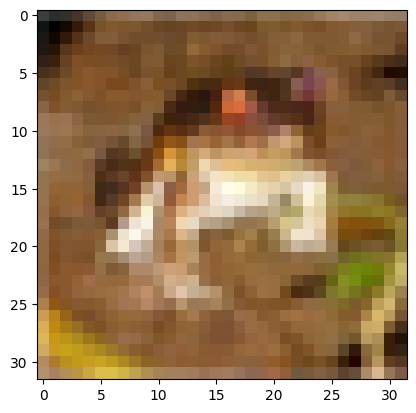

In [9]:
plt.imshow(X_train[0])

Even for a human, this sort of a pixelated image is tough to identify

In [10]:
# This list has been given to us in the documentation for reference
labels = np.array([
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
])

Let's see what it is

In [11]:
y_train[0]

array([6], dtype=uint8)

In [12]:
labels[y_train[0]]

array(['frog'], dtype='<U10')

Well... that was a frog.. but are all pictures going to be like this?

In [13]:
labels[y_train[0]][0]

'frog'

In [14]:
#Scaling the 0-255 values down to 0-1

X_train, X_valid, X_test= X_train/255, X_valid/255, X_test/255

In [15]:
X_train[0][:,1][:5]

array([[0.16862745, 0.18039216, 0.17647059],
       [0.        , 0.        , 0.        ],
       [0.0627451 , 0.02745098, 0.        ],
       [0.14901961, 0.07843137, 0.01568627],
       [0.23137255, 0.1254902 , 0.04313725]])

In [16]:
indices= np.random.choice(40000, 40, replace= False)
indices

array([15086, 17757,  2989, 36035, 16077, 20784, 31694, 30508, 33599,
        6763, 28796, 35736, 35984, 31555,  8573, 29860, 12701, 30031,
       30129, 15654, 24466, 36733, 15599, 13119, 13893, 26298, 18213,
       25511, 21362,  5435,  2886, 28908, 18040, 14169, 39784,  9985,
       24385, 17033, 33291, 15349])

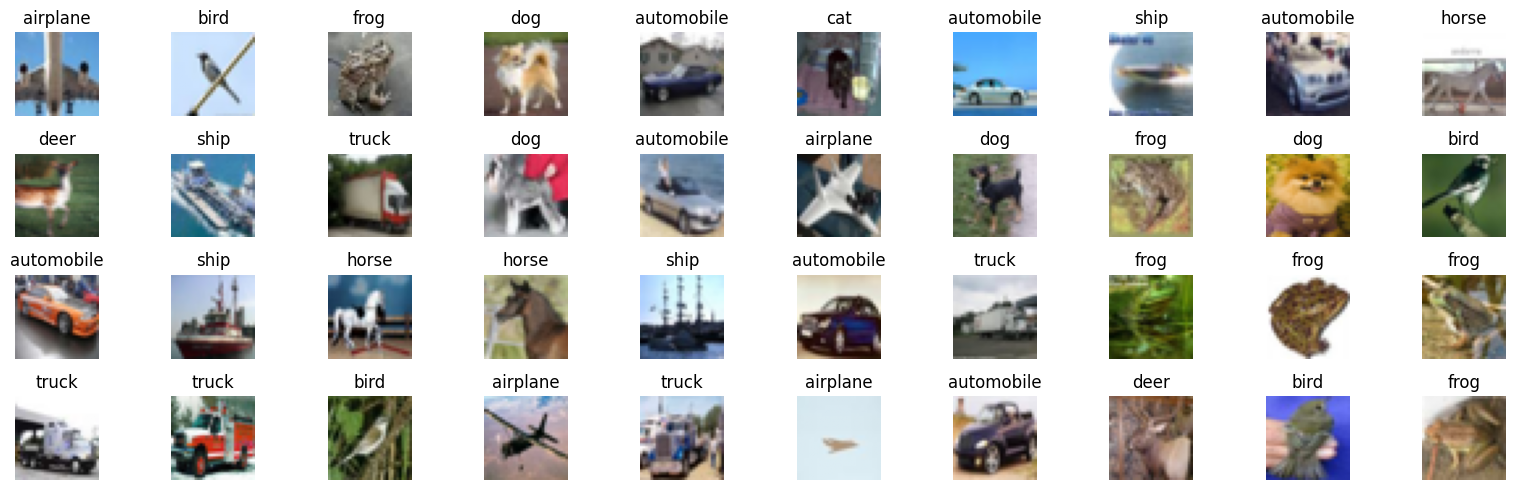

In [17]:
fig, axes= plt.subplots(4,10, figsize= (16,5))

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(labels[y_train[i]][0])
    ax.axis("off")

plt.tight_layout()

Okay, so not all, but definitely some are tough to identify

Looking, at the documentation,   
"You can find some baseline replicable results on this dataset on the project page for cuda-convnet. These results were obtained with a convolutional neural network. Briefly, they are 18% test error without data augmentation and 11% with." 

So if with a CNN, were reaching 18%... let's put a target of 20 with NN first. 

Starting with a basic model, we'll go with a **X (Input)-> 100 -> 80 -> 40 -> 20 -> 10 (Output)**  Neural Network

In [18]:
model1= tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= [32,32, 3]), 
    tf.keras.layers.Dense(100, activation= "relu"), 
    tf.keras.layers.Dense(80, activation= "relu"), 
    tf.keras.layers.Dense(40, activation= "relu"), 
    tf.keras.layers.Dense(20, activation= "relu"), 
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         307,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 80)                  │           8,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 40)                  │           3,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 319,650 (1.22 MB)

 Trainable params: 319,650 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model1.layers[1].get_weights()

[array([[-0.0399789 ,  0.02206583, -0.0010201 , ...,  0.00193247,
         -0.03702107,  0.02659347],
        [-0.02125088,  0.02090189, -0.02303509, ...,  0.0186993 ,
         -0.04063675,  0.02947659],
        [-0.01272839,  0.02189017, -0.03788681, ...,  0.02392958,
          0.02712201,  0.01254983],
        ...,
        [-0.01129907, -0.0386818 ,  0.01017932, ..., -0.03535823,
         -0.01430043,  0.02789712],
        [ 0.02722466,  0.02206056,  0.01867207, ..., -0.02099504,
          0.02537577, -0.04327311],
        [ 0.02891514,  0.00156203,  0.00572794, ..., -0.02069106,
         -0.01635201, -0.01134351]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [21]:
model1.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "sgd", 
              metrics = ["accuracy"])

In [22]:
history = model1.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1978 - loss: 2.1708 - val_accuracy: 0.3198 - val_loss: 1.8951
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3282 - loss: 1.8644 - val_accuracy: 0.3525 - val_loss: 1.7880
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3667 - loss: 1.7574 - val_accuracy: 0.3874 - val_loss: 1.7172
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3969 - loss: 1.6794 - val_accuracy: 0.4035 - val_loss: 1.6728
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4166 - loss: 1.6261 - val_accuracy: 0.4130 - val_loss: 1.6419
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4311 - loss: 1.5905 - val_accuracy: 0.4197 - val_loss: 1.6141
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4459 - loss: 1.5527 - val_accuracy: 0.4449 - val_loss: 1.5650
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4622 - loss: 1.5160 - 

In [23]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 1250}

In [24]:
history.history

{'accuracy': [0.24160000681877136,
  0.336124986410141,
  0.37485000491142273,
  0.4012500047683716,
  0.4215500056743622,
  0.43184998631477356,
  0.44745001196861267,
  0.45797500014305115,
  0.46837499737739563,
  0.475600004196167,
  0.4857249855995178,
  0.48852500319480896,
  0.49380001425743103,
  0.4996750056743622,
  0.5073500275611877,
  0.5143250226974487,
  0.51767498254776,
  0.5246250033378601,
  0.5276749730110168,
  0.5308499932289124,
  0.5373749732971191,
  0.5414749979972839,
  0.5479999780654907,
  0.550849974155426,
  0.5510249733924866,
  0.557449996471405,
  0.5612000226974487,
  0.5648000240325928,
  0.5652750134468079,
  0.5706250071525574,
  0.5774499773979187,
  0.5759249925613403,
  0.5813500285148621,
  0.5829499959945679,
  0.5885249972343445,
  0.5896250009536743,
  0.5936750173568726,
  0.5963000059127808,
  0.5985000133514404,
  0.6009250283241272,
  0.6062250137329102,
  0.6092749834060669,
  0.6112250089645386,
  0.611549973487854,
  0.616349995136261

<Axes: xlabel='Epochs'>

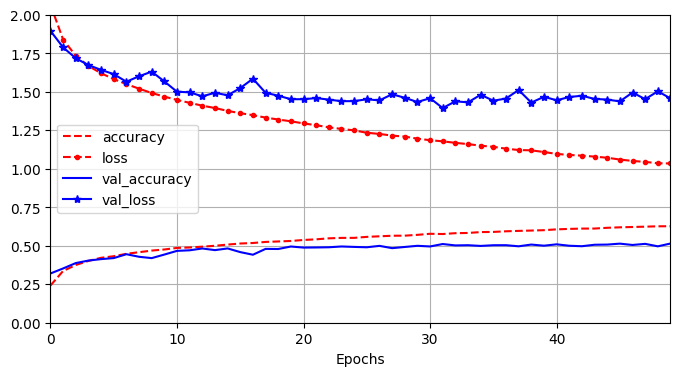

In [25]:
pd.DataFrame(history.history).plot(
    figsize= (8,4), xlim= [0,49], ylim= [0,2], grid= True, xlabel= "Epochs",
    style= ["r--", "r--.", "b-", "b-*"]
)

Hmmm.... Losses are diverging and we are at 0.65 accuracy with training but stagnating at 0.5 for validation

Maybe, Dropout might help us out.. We seem to be overfitting rn *a lil bit*, but also we need to make our model more complicated, right now, 0.5 or even 0.65 in training is off

In [26]:
model2= tf.keras.Sequential([ ## With Dropout
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(300, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(150, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(80, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05),
    tf.keras.layers.Dense(20, activation= "relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model2.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "adam", ## Let's switch to adam as well
              metrics = ["accuracy"])

In [28]:
history = model2.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.1604 - loss: 2.2355 - val_accuracy: 0.2766 - val_loss: 1.9280
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2702 - loss: 1.9440 - val_accuracy: 0.3150 - val_loss: 1.8725
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3154 - loss: 1.8719 - val_accuracy: 0.3502 - val_loss: 1.7983
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3345 - loss: 1.8278 - val_accuracy: 0.3556 - val_loss: 1.7687
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3453 - loss: 1.7932 - val_accuracy: 0.3674 - val_loss: 1.7340
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3525 - loss: 1.7737 - val_accuracy: 0.3702 - val_loss: 1.7286
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3599 - loss: 1.7536 - val_accuracy: 0.3856 - val_loss: 1.6904
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3774 - loss: 1

<Axes: xlabel='Epochs'>

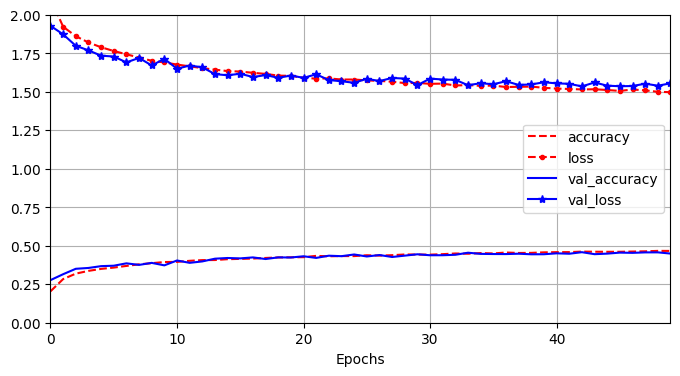

In [29]:
pd.DataFrame(history.history).plot(
    figsize= (8,4), xlim= [0,49], ylim= [0,2], grid= True, xlabel= "Epochs",
    style= ["r--", "r--.", "b-", "b-*"]
)

Dropout has clearly shown to be good enough to stop the difference between training and validation error but our model is simply not complex enough yet.. Let's see a version where it is longer but narrower

Perhaps.. we'll be better off, only applying dropout at the earlier layers?

In [30]:
model3= tf.keras.Sequential([ ## With Dropout
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(300, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(150, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.03), 
    tf.keras.layers.Dense(80, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.02), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dense(20, activation= "relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model3.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "adam", ## Let's switch to adam as well
              metrics = ["accuracy"])

In [32]:
history = model3.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1882 - loss: 2.1587 - val_accuracy: 0.2765 - val_loss: 1.9916
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3096 - loss: 1.8817 - val_accuracy: 0.3543 - val_loss: 1.7994
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3422 - loss: 1.8027 - val_accuracy: 0.3674 - val_loss: 1.7451
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3717 - loss: 1.7307 - val_accuracy: 0.3656 - val_loss: 1.7659
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3902 - loss: 1.6940 - val_accuracy: 0.4084 - val_loss: 1.6469
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3993 - loss: 1.6608 - val_accuracy: 0.4179 - val_loss: 1.6315
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4111 - loss: 1.6232 - val_accuracy: 0.4140 - val_loss: 1.6351
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4203 - loss: 1

There's a little bit of overfitting happening over here, but i we would like to set and build with model3 as default now.

In [33]:
model3.save("cifar_dafault_model.keras")

## Error Analysis

In [35]:
y_valid

array([[1],
       [8],
       [5],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [37]:
y_valid_pred= model3.predict(X_valid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [39]:
y_valid_pred = np.argmax(y_valid_pred, axis=1)

In [54]:
y_valid_pred

array([1, 8, 5, ..., 9, 1, 7], dtype=int64)

<Figure size 640x480 with 0 Axes>

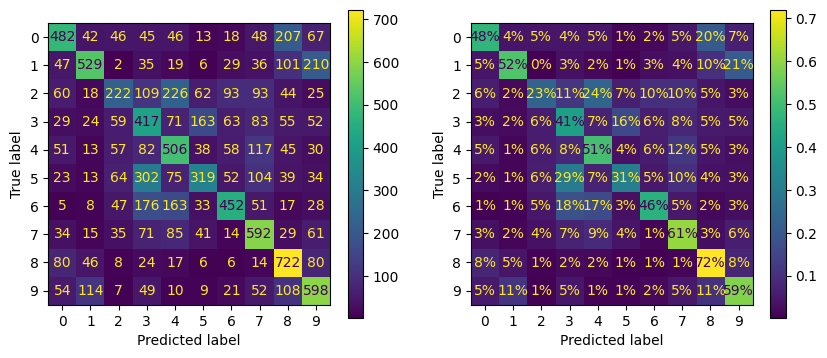

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.clf()
fig, axes= plt.subplots(1,2, figsize = (10,4))

ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, normalize= "true", values_format=".0%", ax= axes[1])
plt.show()

In [43]:
labels

array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
       'horse', 'ship', 'truck'], dtype='<U10')

That gives us a good idea of our predictions, but we want to foccus on where our model is making mistakes

In [59]:
y_valid = y_valid.reshape(-1)

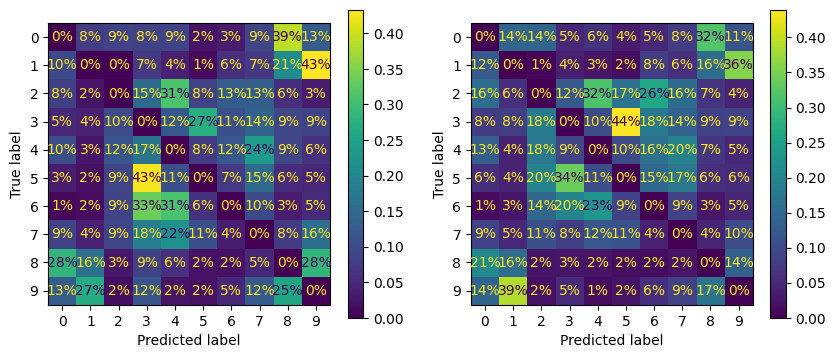

In [60]:
fig, axes= plt.subplots(1,2, figsize = (10,4))
sample_weight = (y_valid_pred != y_valid)

ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[0], sample_weight=sample_weight, normalize= "true", values_format= ".0%")
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[1], sample_weight=sample_weight,normalize= "pred", values_format=".0%")